# Low-resource CRNN synthetic-augmentation experiment

**Question.** If a newly initialized CRNN can see only 50 labeled real
spectrograms per species, do existing VAE-v3 or diffusion spectrograms improve
classification of real held-out clips?

This is a **report-only** companion to the completed matched experiment. It
loads bounded evidence from `reports/crnn_low_resource_augmentation_2026-08-10/`
and never reads checkpoints, trains a model, or generates a spectrogram.

The experiment simulates classifier-label scarcity for the repository's three
common species. It is not evidence about genuinely rare or unseen species.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the bird_song_gen project root")


PROJECT_ROOT = find_project_root(Path.cwd())
REPORT_DIR = PROJECT_ROOT / "reports/crnn_low_resource_augmentation_2026-08-10"
required = [
    "protocol.json",
    "summary.json",
    "validation_selection.csv",
    "test_aggregate.csv",
    "test_per_run.csv",
    "paired_deltas.csv",
    "paired_summary.csv",
    "subset_membership.csv",
    "subset_overlap.csv",
]
missing = [name for name in required if not (REPORT_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"Incomplete report package; missing: {missing}")

protocol = json.loads((REPORT_DIR / "protocol.json").read_text(encoding="utf-8"))
summary = json.loads((REPORT_DIR / "summary.json").read_text(encoding="utf-8"))
validation = pd.read_csv(REPORT_DIR / "validation_selection.csv")
test_aggregate = pd.read_csv(REPORT_DIR / "test_aggregate.csv")
test_per_run = pd.read_csv(REPORT_DIR / "test_per_run.csv")
paired = pd.read_csv(REPORT_DIR / "paired_deltas.csv")
paired_summary = pd.read_csv(REPORT_DIR / "paired_summary.csv")
membership = pd.read_csv(REPORT_DIR / "subset_membership.csv")
subset_overlap = pd.read_csv(REPORT_DIR / "subset_overlap.csv")

COLORS = {"Real only": "#5B6770", "VAE-v3 +200": "#2E86AB", "Diffusion +200": "#E07A5F"}
CONDITION_LABELS = {
    "real_only": "Real only",
    "vae_v3_plus_200": "VAE-v3 +200",
    "diffusion_plus_200": "Diffusion +200",
}
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
print(f"Report package loaded: {REPORT_DIR.relative_to(PROJECT_ROOT)}")

Report package loaded: reports\crnn_low_resource_augmentation_2026-08-10


## 1. Report and schema audit

The notebook first verifies the portable package. This catches an incomplete or
incompatible report before any chart is interpreted.

In [2]:
assert protocol["schema_version"] == 1
assert summary["schema_version"] == 1
assert protocol["real_per_species"] == 50
assert protocol["ratios_per_species"] == [50, 100, 200]
assert len(protocol["replicate_blocks"]) == 9
assert set(summary["selected_ratios"]) == {"vae_v3", "diffusion"}
assert summary["selected_ratios"] == {"vae_v3": 200, "diffusion": 200}

expected_validation = {
    (generator, ratio)
    for generator in ("vae_v3", "diffusion")
    for ratio in (50, 100, 200)
}
assert set(zip(validation["generator"], validation["ratio_per_species"])) == expected_validation
assert validation["runs"].eq(9).all()
assert validation["selected_for_test"].sum() == 2
assert set(test_aggregate["condition"]) == set(CONDITION_LABELS)
assert test_aggregate["runs"].eq(9).all()
assert len(test_per_run) == 27
assert test_per_run["sample_count"].eq(489).all()
assert len(paired) == 18 and paired_summary["paired_blocks"].eq(9).all()

membership_counts = membership.groupby(
    ["low_resource_subset_seed", "name"]
).size()
recording_counts = membership.groupby(
    ["low_resource_subset_seed", "name"]
)["id"].nunique()
assert membership_counts.eq(50).all()
assert recording_counts.eq(50).all()
assert len(membership) == 450
assert len(subset_overlap) == 9

audit = pd.DataFrame(
    {
        "Check": [
            "Matched blocks",
            "Training runs represented in validation",
            "Held-out evaluations",
            "Test clips per evaluation",
            "Real subset rows",
            "Distinct recording IDs per subset/species",
        ],
        "Observed": [9, int(validation["runs"].sum() + 9), 27, 489, 450, 50],
        "Status": ["pass"] * 6,
    }
)
display(audit)
print("Report schema and experiment counts passed.")

,Check,Observed,Status
0,Matched blocks,9,pass
1,Training runs represented in validation,63,pass
2,Held-out evaluations,27,pass
3,Test clips per evaluation,489,pass
4,Real subset rows,450,pass
5,Distinct recording IDs per subset/species,50,pass


Report schema and experiment counts passed.


## 2. Experimental design

- Each real subset contains 50 rows per species, each from a different recording
  ID in `content_safe_v2` training data.
- Three real-subset seeds × three CRNN initialization seeds form nine matched
  blocks. Generation-pool seeds 42, 123, and 777 rotate by Latin square.
- Every block trains a real-only control and VAE-v3/diffusion arms with +50,
  +100, or +200 generated rows per species: 7 conditions × 9 blocks = 63 runs.
- All conditions use the same from-scratch CRNN, 1,440 optimizer steps,
  real-only validation set, and the same post-cache masking policy for real and
  generated training rows.
- Validation chooses one ratio per generator. Test is then used only for the
  real-only controls and the two selected arms.

In [3]:
design = pd.DataFrame(
    {
        "Design element": [
            "Real rows per species",
            "Generated rows per species tested",
            "Real-subset seeds",
            "CRNN training seeds",
            "Generation-pool seeds",
            "Matched blocks",
            "Total CRNN training runs",
            "Held-out test clips",
        ],
        "Value": [
            protocol["real_per_species"],
            ", ".join(map(str, protocol["ratios_per_species"])),
            ", ".join(map(str, protocol["real_subset_seeds"])),
            ", ".join(map(str, protocol["train_seeds"])),
            ", ".join(map(str, protocol["pool_seeds"])),
            len(protocol["replicate_blocks"]),
            63,
            int(test_per_run["sample_count"].iloc[0]),
        ],
    }
)
display(design)

shares = pd.DataFrame(
    {
        "Generated per species": protocol["ratios_per_species"],
        "Real per species": protocol["real_per_species"],
    }
)
shares["Total training rows per species"] = (
    shares["Generated per species"] + shares["Real per species"]
)
shares["Synthetic share"] = (
    shares["Generated per species"] / shares["Total training rows per species"]
)
display(shares.style.format({"Synthetic share": "{:.1%}"}))

,Design element,Value
0,Real rows per species,50
1,Generated rows per species tested,"50, 100, 200"
2,Real-subset seeds,"101, 202, 303"
3,CRNN training seeds,"42, 123, 777"
4,Generation-pool seeds,"42, 123, 777"
5,Matched blocks,9
6,Total CRNN training runs,63
7,Held-out test clips,489


,Generated per species,Real per species,Total training rows per species,Synthetic share
0,50,50,100,50.0%
1,100,50,150,66.7%
2,200,50,250,80.0%


### Real-subset dependence

The subsets use distinct recording IDs *within* a subset, but the three subsets
cannot be disjoint. The source split has only 56 Robin, 63 Cardinal, and 95
Sparrow recording IDs. Therefore, the nine matched blocks support a descriptive
stability analysis, not nine independent external replications.

In [4]:
overlap_view = subset_overlap.rename(
    columns={
        "species": "Species",
        "subset_seed_a": "Subset A",
        "subset_seed_b": "Subset B",
        "shared_recording_ids": "Shared recording IDs",
        "union_recording_ids": "Union recording IDs",
        "jaccard_overlap": "Jaccard overlap",
    }
)
display(overlap_view.style.format({"Jaccard overlap": "{:.1%}"}))

,Species,Subset A,Subset B,Shared recording IDs,Union recording IDs,Jaccard overlap
0,American Robin,101,202,45,55,81.8%
1,American Robin,101,303,44,56,78.6%
2,American Robin,202,303,46,54,85.2%
3,Northern Cardinal,101,202,39,61,63.9%
4,Northern Cardinal,101,303,38,62,61.3%
5,Northern Cardinal,202,303,41,59,69.5%
6,Song Sparrow,101,202,29,71,40.8%
7,Song Sparrow,101,303,27,73,37.0%
8,Song Sparrow,202,303,28,72,38.9%


## 3. Validation-only ratio selection

Both generators selected +200 per species from the mean best validation macro
F1 across nine blocks. The selection rule chooses the smallest ratio within
0.002 of the best mean. Because +200 is the largest existing pool size, it is
the **best tested ratio**, not evidence that performance has saturated or that
200 is the true optimum.

,Generator,Generated/species,Runs,Mean macro F1,Sample SD,Minimum,Maximum,Selected
0,VAE-v3,50,9,84.33%,2.01%,81.65%,87.27%,False
1,VAE-v3,100,9,86.18%,1.70%,83.58%,89.26%,False
2,VAE-v3,200,9,86.67%,2.13%,83.12%,90.04%,True
3,Diffusion,50,9,83.80%,2.65%,79.49%,88.57%,False
4,Diffusion,100,9,84.71%,3.08%,78.53%,89.10%,False
5,Diffusion,200,9,85.09%,3.35%,77.83%,88.42%,True


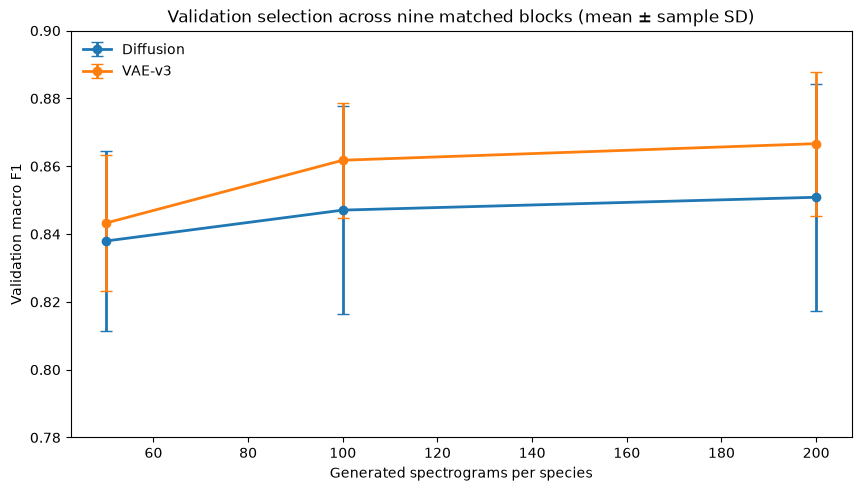

In [5]:
validation_view = validation[
    [
        "generator",
        "ratio_per_species",
        "runs",
        "validation_macro_f1_mean",
        "validation_macro_f1_sample_sd",
        "validation_macro_f1_min",
        "validation_macro_f1_max",
        "selected_for_test",
    ]
].copy()
validation_view["generator"] = validation_view["generator"].map(
    {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
)
validation_view = validation_view.rename(
    columns={
        "generator": "Generator",
        "ratio_per_species": "Generated/species",
        "runs": "Runs",
        "validation_macro_f1_mean": "Mean macro F1",
        "validation_macro_f1_sample_sd": "Sample SD",
        "validation_macro_f1_min": "Minimum",
        "validation_macro_f1_max": "Maximum",
        "selected_for_test": "Selected",
    }
)
display(
    validation_view.style.format(
        {
            "Mean macro F1": "{:.2%}",
            "Sample SD": "{:.2%}",
            "Minimum": "{:.2%}",
            "Maximum": "{:.2%}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
for generator, group in validation_view.groupby("Generator"):
    ordered = group.sort_values("Generated/species")
    ax.errorbar(
        ordered["Generated/species"],
        ordered["Mean macro F1"],
        yerr=ordered["Sample SD"],
        marker="o",
        capsize=4,
        linewidth=2,
        label=generator,
    )
ax.set(
    xlabel="Generated spectrograms per species",
    ylabel="Validation macro F1",
    ylim=(0.78, 0.90),
    title="Validation selection across nine matched blocks (mean ± sample SD)",
)
ax.legend(frameon=False)
plt.show()

## 4. Held-out classifier utility

The primary comparison is paired within each real-subset/training-seed block.
The interval below is a deterministic bootstrap over the nine matched blocks.
It is a descriptive stability summary—not a p-value, not a confidence interval
over test recordings, and not evidence from nine independent datasets.

In [6]:
aggregate_view = test_aggregate[
    [
        "condition",
        "runs",
        "accuracy_mean",
        "accuracy_sample_sd",
        "macro_f1_mean",
        "macro_f1_sample_sd",
        "macro_f1_min",
        "macro_f1_max",
        "minimum_species_recall_mean",
    ]
].copy()
aggregate_view["condition"] = aggregate_view["condition"].map(CONDITION_LABELS)
aggregate_view = aggregate_view.rename(
    columns={
        "condition": "Condition",
        "runs": "Runs",
        "accuracy_mean": "Mean accuracy",
        "accuracy_sample_sd": "Accuracy SD",
        "macro_f1_mean": "Mean macro F1",
        "macro_f1_sample_sd": "Macro-F1 SD",
        "macro_f1_min": "Macro-F1 minimum",
        "macro_f1_max": "Macro-F1 maximum",
        "minimum_species_recall_mean": "Mean worst-species recall",
    }
)
display(
    aggregate_view.style.format(
        {column: "{:.2%}" for column in aggregate_view.columns if column not in {"Condition", "Runs"}}
    )
)

paired_view = paired_summary[
    [
        "generator",
        "selected_ratio_per_species",
        "paired_blocks",
        "delta_macro_f1_mean",
        "delta_macro_f1_sample_sd",
        "delta_macro_f1_min",
        "delta_macro_f1_max",
        "delta_macro_f1_bootstrap_95_low",
        "delta_macro_f1_bootstrap_95_high",
        "delta_macro_f1_positive_blocks",
    ]
].copy()
paired_view["generator"] = paired_view["generator"].map(
    {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
)
paired_view = paired_view.rename(
    columns={
        "generator": "Generator",
        "selected_ratio_per_species": "Selected generated/species",
        "paired_blocks": "Blocks",
        "delta_macro_f1_mean": "Mean paired delta",
        "delta_macro_f1_sample_sd": "Delta SD",
        "delta_macro_f1_min": "Minimum delta",
        "delta_macro_f1_max": "Maximum delta",
        "delta_macro_f1_bootstrap_95_low": "Interval low",
        "delta_macro_f1_bootstrap_95_high": "Interval high",
        "delta_macro_f1_positive_blocks": "Positive blocks",
    }
)
display(
    paired_view.style.format(
        {
            "Mean paired delta": "{:+.2%}",
            "Delta SD": "{:.2%}",
            "Minimum delta": "{:+.2%}",
            "Maximum delta": "{:+.2%}",
            "Interval low": "{:+.2%}",
            "Interval high": "{:+.2%}",
        }
    )
)

,Condition,Runs,Mean accuracy,Accuracy SD,Mean macro F1,Macro-F1 SD,Macro-F1 minimum,Macro-F1 maximum,Mean worst-species recall
0,Real only,9,84.78%,2.42%,84.75%,2.52%,81.02%,90.00%,75.38%
1,VAE-v3 +200,9,87.64%,1.35%,87.69%,1.37%,85.75%,90.24%,81.68%
2,Diffusion +200,9,85.23%,2.20%,85.17%,2.23%,81.41%,88.10%,77.78%


,Generator,Selected generated/species,Blocks,Mean paired delta,Delta SD,Minimum delta,Maximum delta,Interval low,Interval high,Positive blocks
0,Diffusion,200,9,+0.42%,2.53%,-4.41%,+3.00%,-1.19%,+1.85%,5
1,VAE-v3,200,9,+2.93%,2.55%,-0.22%,+7.56%,+1.43%,+4.54%,8


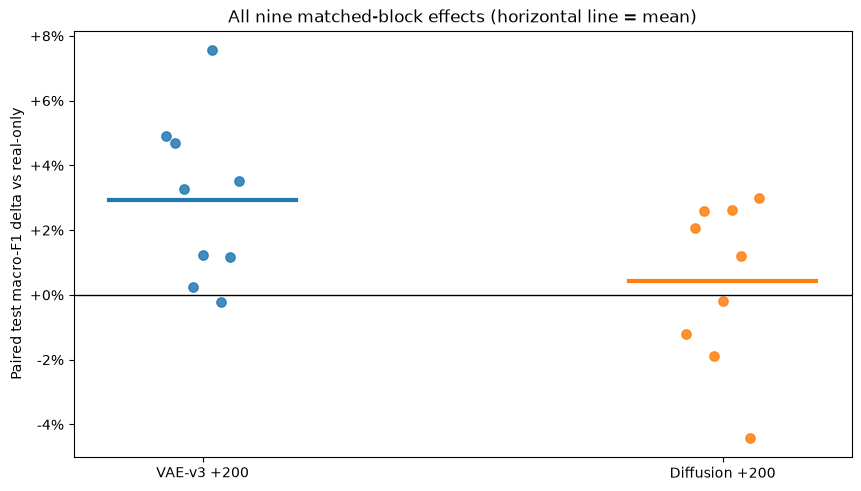

,Generator,Real-subset seed,CRNN seed,Pool seed,Paired macro-F1 delta
0,VAE-v3,101,42,42.000000,+4.90%
1,VAE-v3,101,123,123.000000,+4.70%
2,VAE-v3,101,777,777.000000,+3.27%
3,VAE-v3,202,42,123.000000,+0.24%
4,VAE-v3,202,123,777.000000,+1.24%
5,VAE-v3,202,777,42.000000,+7.56%
6,VAE-v3,303,42,777.000000,-0.22%
7,VAE-v3,303,123,42.000000,+1.18%
8,VAE-v3,303,777,123.000000,+3.53%
9,Diffusion,101,42,42.000000,-1.21%


In [7]:
plot_data = paired.copy()
plot_data["Generator"] = plot_data["generator"].map(
    {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
)
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
positions = {"VAE-v3": 0, "Diffusion": 1}
ax.axhline(0, color="black", linewidth=1)
for generator, group in plot_data.groupby("Generator", sort=False):
    x = positions[generator]
    jitter = np.linspace(-0.07, 0.07, len(group))
    ax.scatter(
        np.full(len(group), x) + jitter,
        group["delta_macro_f1"],
        s=45,
        alpha=0.85,
        label=generator,
    )
    ax.plot([x - 0.18, x + 0.18], [group["delta_macro_f1"].mean()] * 2, linewidth=3)
ax.set(
    xticks=[0, 1],
    xticklabels=["VAE-v3 +200", "Diffusion +200"],
    ylabel="Paired test macro-F1 delta vs real-only",
    title="All nine matched-block effects (horizontal line = mean)",
)
ax.yaxis.set_major_formatter(lambda value, position: f"{value:+.0%}")
plt.show()

block_view = paired[
    ["generator", "real_subset_seed", "train_seed", "pool_seed", "delta_macro_f1"]
].copy()
block_view["generator"] = block_view["generator"].map(
    {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
)
block_view = block_view.rename(
    columns={
        "generator": "Generator",
        "real_subset_seed": "Real-subset seed",
        "train_seed": "CRNN seed",
        "pool_seed": "Pool seed",
        "delta_macro_f1": "Paired macro-F1 delta",
    }
)
display(block_view.style.format({"Paired macro-F1 delta": "{:+.2%}"}))

## 5. Species recall

Macro F1 gives each species equal weight, but it can hide which class changes.
The table below compares mean recall across the same nine blocks.

,Condition,Species,Mean recall,Delta vs real-only
0,Real only,American Robin,90.57%,+0.00%
1,VAE-v3 +200,American Robin,94.18%,+3.60%
2,Diffusion +200,American Robin,91.11%,+0.54%
3,Real only,Northern Cardinal,75.38%,+0.00%
4,VAE-v3 +200,Northern Cardinal,81.96%,+6.58%
5,Diffusion +200,Northern Cardinal,77.78%,+2.40%
6,Real only,Song Sparrow,88.52%,+0.00%
7,VAE-v3 +200,Song Sparrow,87.48%,-1.04%
8,Diffusion +200,Song Sparrow,87.18%,-1.34%


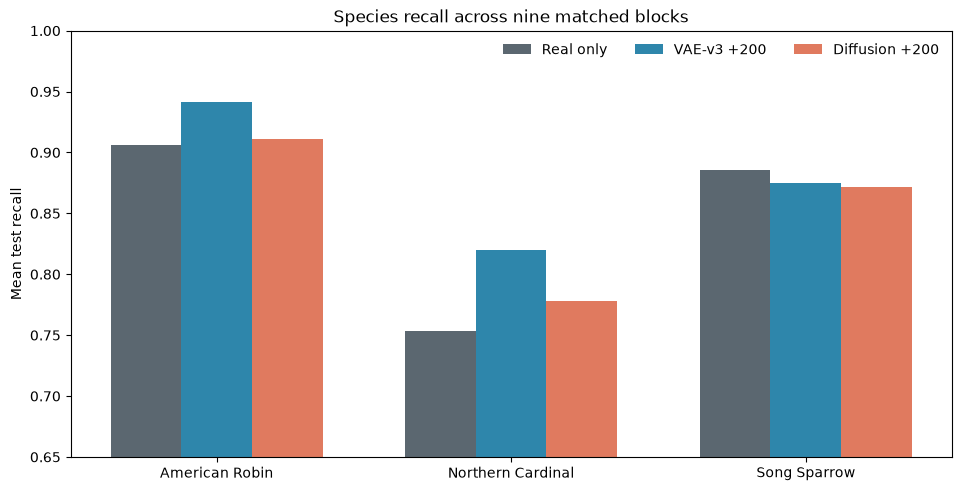

In [8]:
species_columns = {
    "recall_american_robin_mean": "American Robin",
    "recall_northern_cardinal_mean": "Northern Cardinal",
    "recall_song_sparrow_mean": "Song Sparrow",
}
species = test_aggregate[["condition", *species_columns]].copy()
species["condition"] = species["condition"].map(CONDITION_LABELS)
species = species.rename(columns={"condition": "Condition", **species_columns})
baseline = species.loc[species["Condition"] == "Real only"].iloc[0]

species_long = species.melt(
    id_vars="Condition", var_name="Species", value_name="Mean recall"
)
species_long["Delta vs real-only"] = species_long.apply(
    lambda row: row["Mean recall"] - baseline[row["Species"]], axis=1
)
display(
    species_long.style.format(
        {"Mean recall": "{:.2%}", "Delta vs real-only": "{:+.2%}"}
    )
)

fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
species_names = list(species_columns.values())
x = np.arange(len(species_names))
width = 0.24
for index, (_, row) in enumerate(species.iterrows()):
    values = [row[name] for name in species_names]
    ax.bar(
        x + (index - 1) * width,
        values,
        width,
        label=row["Condition"],
        color=COLORS[row["Condition"]],
    )
ax.set(
    xticks=x,
    xticklabels=species_names,
    ylabel="Mean test recall",
    ylim=(0.65, 1.0),
    title="Species recall across nine matched blocks",
)
ax.legend(frameon=False, ncols=3)
plt.show()

## 6. Answer and limitations

**Result within this protocol:**

- **VAE-v3 +200/species supports the classifier-utility claim.** Mean test macro
  F1 rose from 84.75% to 87.69%: a paired gain of **2.93 percentage points**.
  Eight of nine blocks improved, with a descriptive block-bootstrap interval of
  +1.43 to +4.54 points. Mean Cardinal recall increased by 6.58 points and Robin
  recall by 3.60 points; Sparrow recall decreased by 1.04 points.
- **Diffusion +200/species did not demonstrate a stable gain.** Mean test macro
  F1 was 85.17%, only +0.42 points over real-only. Five of nine blocks improved,
  and the descriptive interval (-1.19 to +1.85 points) spans both harm and gain.

**What this supports:** With access to the already-trained VAE-v3 and its
existing pools, synthetic spectrograms can help this CRNN under a simulated
50-labels-per-species constraint.

**What this does not support:**

- The three evaluated species are not rare or unseen.
- The pretrained generators saw more source data than the classifier-visible
  50 examples per species.
- The real subsets overlap and the nine blocks are not independent datasets.
- Generation-pool seed is rotated rather than fully crossed with every subset
  and CRNN seed, so all interactions cannot be separated.
- The 489-clip test set has prior project evaluation history and is not a new
  external holdout.
- +200 is the largest available ratio, so the study does not locate an optimum.
- Classifier utility does not establish spectrogram realism, waveform quality,
  or human-perceived quality.

For a stronger rare-species claim, repeat the same matched design on genuinely
rare species with a new external test set and a generator whose training-data
exposure is explicitly documented.

## Reproduction boundary

The full experiment is implemented by
`scripts/15_crnn_low_resource_augmentation.py`. From the repository root:

```powershell
$env:PYTHONPATH = (Resolve-Path "src").Path
& ..\bird_song_venv\Scripts\python.exe `
  scripts/15_crnn_low_resource_augmentation.py audit
& ..\bird_song_venv\Scripts\python.exe `
  scripts/15_crnn_low_resource_augmentation.py run --device cuda --workers 0
```

The command reuses existing VAE-v3 and diffusion arrays. It trains only the
CRNN conditions, keeps checkpoints and histories under ignored `runs/`, and
promotes only bounded evidence to `reports/`.